<a href="https://colab.research.google.com/github/PrMorales/IPCA_Boletim-Focus/blob/main/IPCA_DATA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

importação de bibliotecas

In [ ]:
import pandas as pd
import requests

import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd
import requests

def obter_ipca_realizado():
    # Coleta da série histórica do IPCA mensal via SGS
    url = "https://api.bcb.gov.br/dados/serie/bcdata.sgs.433/dados?formato=json"
    df = pd.read_json(url)
    df['data'] = pd.to_datetime(df['data'], dayfirst=True)
    df.rename(columns={'valor': 'ipca_real'}, inplace=True)
    return df


In [ ]:
# Criando o DataFrame chamando a função de extração
df_ipca = obter_ipca_realizado()

In [ ]:
#olhando para os dados
df_ipca.head()

,data,ipca_real
0,1980-01-01,6.62
1,1980-02-01,4.62
2,1980-03-01,6.04
3,1980-04-01,5.29
4,1980-05-01,5.70


In [ ]:
# checar os tipos de colunas (se a data virou datetime ou continuou texto)
df_ipca.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 557 entries, 0 to 556
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   data       557 non-null    datetime64[ns]
 1   ipca_real  557 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 8.8 KB


In [ ]:
# checar se não há nada faltando na série
df_ipca.isna().sum()

,0
data,0
ipca_real,0


In [ ]:
# olhar para os números: máximos, mínimos e médias históricas
# olhar para o describe é importante pois ajuda a encontrar outliers, se o mercado é estável ou se há grandes assimetrias.
df_ipca.describe()

,data,ipca_real
count,557,557.000000
mean,2003-03-02 07:27:15.188509824,5.530628
min,1980-01-01 00:00:00,-0.680000
25%,1991-08-01 00:00:00,0.360000
50%,2003-03-01 00:00:00,0.710000
75%,2014-10-01 00:00:00,6.400000
max,2026-05-01 00:00:00,82.390000
std,NaN,10.546130


A análise inicial dos dados revelou a presença do período de hiperinflação brasileira, com picos mensais superiores a 80%. Para uma comparação justa com o Boletim Focus atual, decidi filtrar o dataset apenas para o período pós-Plano Real.

Identificou-se uma forte distorção na média histórica (5.5%) em relação à mediana (0.71%), comprovando a necessidade de tratar os outliers históricos antes de calcular qualquer erro de previsão.

In [ ]:
df_ipca_filtrado = df_ipca[df_ipca['data'] >= '2010-01-01']

# Olhando o novo describe
df_ipca_filtrado.describe()

,data,ipca_real
count,197,197.000000
mean,2018-03-02 01:13:05.786801920,0.473299
min,2010-01-01 00:00:00,-0.680000
25%,2014-02-01 00:00:00,0.240000
50%,2018-03-01 00:00:00,0.450000
75%,2022-04-01 00:00:00,0.690000
max,2026-05-01 00:00:00,1.620000
std,NaN,0.357220


Agora podemos notar que a média e a mediana estão bem próximas, em estatística isso significa que os dados têm uma "distribuição normal".

Desvio padrão: sso significa que, neste período de 16 anos, a inflação do Brasil oscilou, em média, apenas 0,35 pontos percentuais para cima ou para baixo a cada mês. É um ambiente muito mais previsível para o mercado financeiro operar do que a década de 80.  

O Máximo (1.62%): O teto inflacionário mensal deste recorte não passa de 2%. Historicamente, picos assim ocorreram na crise hídrica/tarifária de 2015 ou nos choques de oferta da pandemia (2021).
O Mínimo (-0.68%): Tivemos deflação profunda. Para quem conhece o contexto econômico, sabe que esse -0.68% ocorreu provavelmente em Julho de 2022, quando o governo forçou um corte de impostos (ICMS) sobre combustíveis e energia.


In [ ]:
# criando uma cópia dos dados
df_viz = df_ipca_filtrado.copy()

In [ ]:
# px.line é uma forma de fazer gráficos interativos rápidos usando plotly
fig_linha = px.line(
    df_viz,
    x='data',
    y='ipca_real',
    title='Raio-X da Inflação: Evolução do IPCA (2010-2026)',
    labels={'data': 'Período', 'ipca_real': 'Variação Mensal (%)'},
    template='plotly_white'
)
# Preenchendo a área sob a curva
fig_linha.update_traces(fill='tozeroy', line=dict(color='#2563eb', width=2.5))

# Adicionando contexto histórico.
fig_linha.add_annotation(x='2015-09-01', y=1.32, text='Crise Hídrica/Dilma', showarrow=True, arrowhead=1, ax=0, ay=-40)
fig_linha.add_annotation(x='2020-04-01', y=-0.31, text='Choque Pandemia', showarrow=True, arrowhead=1, ax=0, ay=40)
fig_linha.add_annotation(x='2022-07-01', y=-0.68, text='Canetada do ICMS', showarrow=True, arrowhead=1, ax=0, ay=-50)

# Exibe o gráfico interativo
fig_linha.show()



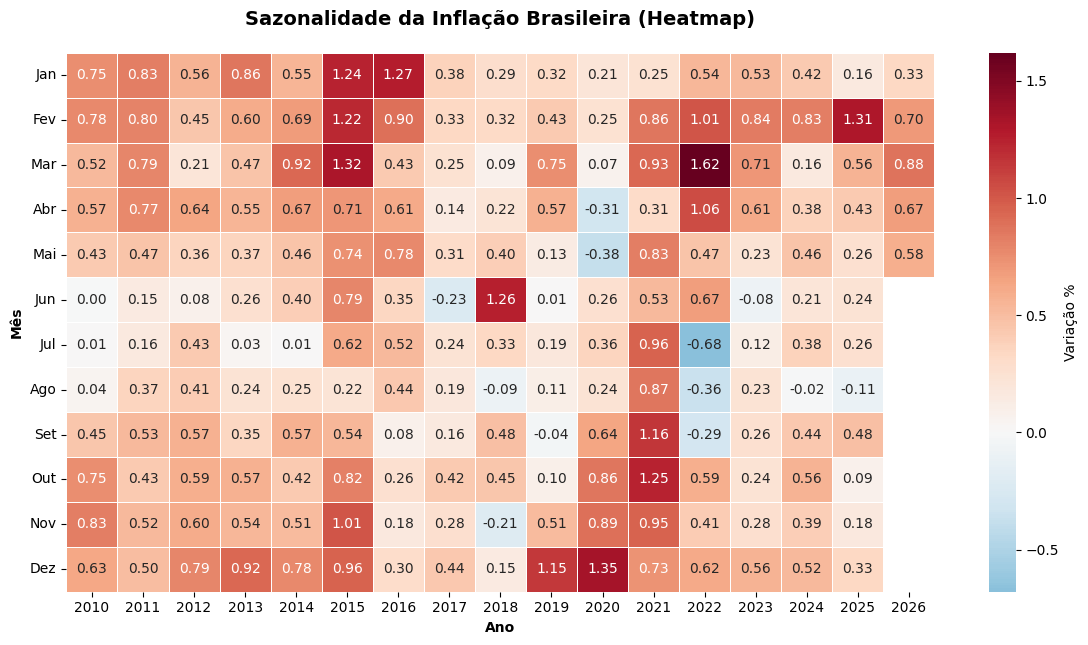

In [ ]:
#GRÁFICO 2: Mapa de Calor
# ==============================================================================

# Extraindo ano e mês.
df_viz['ano'] = df_viz['data'].dt.year
df_viz['mes'] = df_viz['data'].dt.month

# Pivotando a base.
df_pivot = df_viz.pivot_table(index='mes', columns='ano', values='ipca_real')

# Trocando os números dos meses por nomes para facilitar a leitura
meses_nomes = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

# Pega só até o mês máximo disponível pra não dar erro de tamanho no array
df_pivot.index = meses_nomes[:len(df_pivot.index)]

# Configurando o canvas do Matplotlib
plt.figure(figsize=(14, 7))
plt.title('Sazonalidade da Inflação Brasileira (Heatmap)', pad=20, fontsize=14, fontweight='bold')

# cmap='RdBu_r': Azul para deflação (frio/bom), Vermelho para inflação alta (quente/ruim).
# annot=True bota os numerozinhos dentro dos quadrados.
sns.heatmap(
    df_pivot,
    cmap='RdBu_r',
    annot=True,
    fmt=".2f",
    linewidths=.5,
    center=0,
    cbar_kws={'label': 'Variação %'}
)

plt.xlabel('Ano', fontweight='bold')
plt.ylabel('Mês', fontweight='bold')
plt.yticks(rotation=0) # Deixa os meses deitados pra facilitar a leitura

# Exibir
plt.show()

In [ ]:
# GRÁFICO 3: IPCA Acumulado 12 Meses (A Métrica que Derruba Governos)

# Inflação não se soma, capitaliza-se. Fórmulal: ((1 + i1) * (1 + i2) ... ) - 1
df_viz['ipca_12m'] = (
    (1 + df_viz['ipca_real'] / 100)
    .rolling(window=12) # Janela deslizante de 12 meses
    .apply(lambda x: (x.prod() - 1) * 100, raw=False)
)

# Plotando o acumulado
fig_acumulado = px.line(
    df_viz.dropna(subset=['ipca_12m']),
    x='data',
    y='ipca_12m',
    title='IPCA Acumulado em 12 Meses',
    labels={'data': 'Período', 'ipca_12m': 'Acumulado 12m (%)'},
    template='plotly_white'
)

fig_acumulado.update_traces(fill='tozeroy', line=dict(color='#dc2626', width=2.5))

# Colocando uma linha de referência. Teto da meta em vários anos girou em torno de 4.5% a 6.5%.
# Vamos usar 6.5% para mostrar os momentos de estouro real do teto.
fig_acumulado.add_hline(y=6.5, line_dash="dash", line_color="gray", annotation_text="Teto Histórico da Meta (Ref: 6.5%)")

fig_acumulado.show()

In [ ]:
import pandas as pd
import requests

def obter_expectativas_focus():
    print("A extrair dados do Oráculo (Boletim Focus)...")

    url = (
        "https://olinda.bcb.gov.br/olinda/servico/Expectativas/versao/v1/odata/"
        "ExpectativaMercadoMensais?$top=50000"
        "&$filter=Indicador%20eq%20'IPCA'%20and%20Data%20ge%20'2009-12-01'"
        "&$select=Data,DataReferencia,Mediana"
        "&$format=json"
    )

    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers=headers)

    if response.status_code != 200:
        raise Exception(f"Erro na API: {response.status_code} - {response.text}")

    data = response.json()
    df_focus = pd.DataFrame(data['value'])

    # Processamento de datas e colunas
    df_focus['Data'] = pd.to_datetime(df_focus['Data'])
    df_focus['DataReferencia'] = pd.to_datetime(df_focus['DataReferencia'], format='%m/%Y')

    df_focus.rename(columns={
        'Mediana': 'ipca_projetado',
        'Data': 'data_projecao',
        'DataReferencia': 'data_referencia'
    }, inplace=True)

    # Filtro: Projeções feitas antes da referência
    df_focus_previo = df_focus[df_focus['data_projecao'] < df_focus['data_referencia']].copy()
    idx_ultimas = df_focus_previo.groupby('data_referencia')['data_projecao'].idxmax()

    return df_focus_previo.loc[idx_ultimas].reset_index(drop=True)

In [ ]:
df_focus = obter_expectativas_focus()

A extrair dados do Oráculo (Boletim Focus)...


In [ ]:
df_focus.head()

,data_projecao,data_referencia,ipca_projetado
0,2022-07-29,2022-08-01,-0.1100
1,2022-08-31,2022-09-01,0.3252
2,2022-09-30,2022-10-01,0.3400
3,2022-10-31,2022-11-01,0.4000
4,2022-11-30,2022-12-01,0.6400


In [ ]:
df_focus.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   data_projecao    71 non-null     datetime64[ns]
 1   data_referencia  71 non-null     datetime64[ns]
 2   ipca_projetado   71 non-null     float64       
dtypes: datetime64[ns](2), float64(1)
memory usage: 1.8 KB


In [ ]:
df_focus.describe()

,data_projecao,data_referencia,ipca_projetado
count,71,71,71.000000
mean,2025-03-02 06:45:38.028168960,2025-07-01 12:10:08.450704128,0.363139
min,2022-07-29 00:00:00,2022-08-01 00:00:00,-0.110000
25%,2024-01-14 12:00:00,2024-01-16 12:00:00,0.283850
50%,2025-06-30 00:00:00,2025-07-01 00:00:00,0.340000
75%,2026-06-26 00:00:00,2026-12-16 12:00:00,0.460000
max,2026-06-26 00:00:00,2028-06-01 00:00:00,1.375000
std,NaN,NaN,0.204084


# **CRUZAMENTO DE DADOS** - EXPECTATIVA X REALIDADE

In [ ]:
import pandas as pd
import plotly.graph_objects as go

# 1. Cruzamento das duas bases (Merge Interno)
# Alinha o IPCA real com a projeção feita para aquele mesmo mês
df_final = pd.merge(
    df_ipca_filtrado,
    df_focus,
    left_on='data',
    right_on='data_referencia',
    how='inner'
)

# 2. Cálculos dos Erros de Previsão
df_final['erro_direcional'] = df_final['ipca_real'] - df_final['ipca_projetado']
df_final['erro_absoluto'] = df_final['erro_direcional'].abs()

# Ordena por data para garantir que o gráfico de linha siga a ordem cronológica
df_final = df_final.sort_values('data').reset_index(drop=True)

# 3. Construção do Gráfico Interativo (Plotly Graph Objects)
fig = go.Figure()

# Linha 1: IPCA real
fig.add_trace(go.Scatter(
    x=df_final['data'],
    y=df_final['ipca_real'],
    mode='lines+markers',
    name='IPCA Realizado (IBGE)',
    line=dict(color='#2563eb', width=3),
    marker=dict(size=5),
    hovertemplate='%{y:.2f}%'
))

# Linha 2: Projeção do Boletim Focus
fig.add_trace(go.Scatter(
    x=df_final['data'],
    y=df_final['ipca_projetado'],
    mode='lines+markers',
    name='Projeção Focus (BCB)',
    line=dict(color='#f59e0b', width=2.5, dash='dash'),
    marker=dict(size=5),
    hovertemplate='%{y:.2f}%'
))

# Customização técnica do Layout
fig.update_layout(
    title=dict(
        text='<b>Expectativa vs. Realidade: IPCA Realizado vs. Projeção Focus (1M Antes)</b>',
        font=dict(size=16)
    ),
    xaxis=dict(title='Período', showgrid=True, gridcolor='#e5e7eb'),
    yaxis=dict(title='Variação Mensal (%)', showgrid=True, gridcolor='#e5e7eb'),
    template='plotly_white',
    hovermode='x unified', # Junta os balões de informação ao passar o mouse
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01, bgcolor='rgba(255,255,255,0.8)')
)

# Anotação de contexto técnico para a janela de dados pós-2022
fig.add_annotation(
    x='2022-11-01',
    y=0.45,
    text='Efeito Rebote pós-ICMS',
    showarrow=True,
    arrowhead=1,
    ax=0,
    ay=-40
)
fig.show()

# 4. Auditoria de Performance
print("="*60)
print(f"Métricas de Performance das Previsões (Período: {df_final['data'].min().strftime('%m/%Y')} a {df_final['data'].max().strftime('%m/%Y')})")
print("="*60)
print(f"Erro Médio Absoluto (MAE): {df_final['erro_absoluto'].mean():.4f} pontos percentuais")
print(f"Maior subestimação do mercado: {df_final['erro_direcional'].max():.2f}%")
print(f"Maior superestimação do mercado: {df_final['erro_direcional'].min():.2f}%")
print("-"*60)
print("\nTop 5 Meses com Maiores Desvios de Previsão:")
print(df_final.sort_values(by='erro_absoluto', ascending=False)[['data', 'ipca_real', 'ipca_projetado', 'erro_direcional']].head())

Métricas de Performance das Previsões (Período: 08/2022 a 05/2026)
Erro Médio Absoluto (MAE): 0.1363 pontos percentuais
Maior subestimação do mercado: 0.56%
Maior superestimação do mercado: -0.62%
------------------------------------------------------------

Top 5 Meses com Maiores Desvios de Previsão:
         data  ipca_real  ipca_projetado  erro_direcional
1  2022-09-01      -0.29          0.3252          -0.6152
43 2026-03-01       0.88          0.3200           0.5600
10 2023-06-01      -0.08          0.3050          -0.3850
0  2022-08-01      -0.36         -0.1100          -0.2500
2  2022-10-01       0.59          0.3400           0.2500


In [ ]:
# Filtra as projeções para os próximos 6 meses
proximos_6m = df_focus[df_focus['data_referencia'] >= '2026-07-01'].head(6)

# Mostra a data e a aposta do mercado
print(proximos_6m[['data_referencia', 'ipca_projetado']])

   data_referencia  ipca_projetado
47      2026-07-01            0.30
48      2026-08-01           -0.01
49      2026-09-01            0.45
50      2026-10-01            0.29
51      2026-11-01            0.28
52      2026-12-01            0.46


In [ ]:
import pandas as pd
import plotly.graph_objects as go

# 1. Filtra a base original do Focus apenas para os anos desejados
df_comp_focus = df_focus[df_focus['data_referencia'].dt.year.isin([2025, 2026])].copy()

# 2. Extrai mês e ano para o agrupamento
df_comp_focus['ano'] = df_comp_focus['data_referencia'].dt.year
df_comp_focus['mes'] = df_comp_focus['data_referencia'].dt.month

# 3. Tabela Dinâmica do "Oráculo"
tabela_focus = df_comp_focus.pivot(index='mes', columns='ano', values='ipca_projetado')

# Nomeando os meses para humanos lerem
meses = {1:'Jan', 2:'Fev', 3:'Mar', 4:'Abr', 5:'Mai', 6:'Jun', 7:'Jul', 8:'Ago', 9:'Set', 10:'Out', 11:'Nov', 12:'Dez'}
tabela_focus.rename(index=meses, inplace=True)

# Calcula a diferença para ver em qual ano eles estavam mais pessimistas
if 2025 in tabela_focus.columns and 2026 in tabela_focus.columns:
    tabela_focus['Diferença (pp)'] = tabela_focus[2026] - tabela_focus[2025]

print("--- O Oráculo: Projeções 2025 vs 2026 ---")
print(tabela_focus.fillna('-'))

# 4. Gráfico de Barras Agrupadas
fig = go.Figure()

if 2025 in tabela_focus.columns:
    fig.add_trace(go.Bar(
        x=tabela_focus.index,
        y=tabela_focus[2025],
        name='Projeção 2025',
        marker_color='#fcd34d' # Amarelo claro
    ))

if 2026 in tabela_focus.columns:
    fig.add_trace(go.Bar(
        x=tabela_focus.index,
        y=tabela_focus[2026],
        name='Projeção 2026',
        marker_color='#d97706' # Laranja escuro
    ))

fig.update_layout(
    title=dict(text='<b>Futurologia Lado a Lado: Focus 2025 vs 2026</b>', font=dict(size=16)),
    xaxis_title='Mês',
    yaxis_title='IPCA Projetado (%)',
    barmode='group',
    template='plotly_white',
    legend=dict(yanchor="top", y=0.99, xanchor="right", x=0.99)
)

fig.show()

--- O Oráculo: Projeções 2025 vs 2026 ---
ano    2025    2026  Diferença (pp)
mes                                
Jan  0.0000  0.3550          0.3550
Fev  1.3750  0.5300         -0.8450
Mar  0.5000  0.3200         -0.1800
Abr  0.4800  0.4700         -0.0100
Mai  0.3800  0.3917          0.0117
Jun  0.3500  0.3100         -0.0400
Jul  0.2000  0.3000          0.1000
Ago -0.0500 -0.0100          0.0400
Set  0.5800  0.4500         -0.1300
Out  0.3000  0.2900         -0.0100
Nov  0.2006  0.2800          0.0794
Dez  0.4700  0.4600         -0.0100
